# Modeling — Dự báo Nguy cơ Trả hàng (Order Return Prediction)

Notebook này xây dựng và đánh giá các mô hình phân loại nhị phân cho bài toán
dự đoán trả hàng ở cấp **đơn hàng** (`order_id`).

## Pipeline

```
1. Load Features → 2. Encode Categoricals → 3. Train/Test Split (Temporal)
   → 4. Baseline Models → 5. Advanced Models (LightGBM, XGBoost)
   → 6. Evaluation (AUC-ROC, F1, PR Curve) → 7. Feature Importance (SHAP)
   → 8. Error Analysis → 9. Cross-Validation
```

## 1. Khởi tạo Môi trường

In [45]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
if os.path.exists('datathon-2026-round-1'):
    DATA_DIR = 'datathon-2026-round-1'
elif os.path.exists('../datathon-2026-round-1'):
    DATA_DIR = '../datathon-2026-round-1'
else:
    raise FileNotFoundError("Không tìm thấy thư mục datathon-2026-round-1!")
print('Thư viện đã sẵn sàng!')

Thư viện đã sẵn sàng!


## 2. Tải dữ liệu đã Feature Engineering

In [46]:
# Tải feature config
with open(os.path.join(DATA_DIR, 'return_prediction_feature_config_v2.json'), 'r') as f:
    config = json.load(f)

ID_COLS = config['id_columns']
TARGET_COL = config['target_column']
NUMERIC_FEATURES = config['numeric_features']
CATEGORICAL_FEATURES = config['categorical_features']
CUTOFF_DATE = config['cutoff_date']

print(f'Feature config loaded!')
print(f'  Granularity: {config.get("granularity", "order_id")}')
print(f'  Numeric features: {len(NUMERIC_FEATURES)}')
print(f'  Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'  Cutoff date: {CUTOFF_DATE}')

Feature config loaded!
  Granularity: order_id
  Numeric features: 54
  Categorical features: 8
  Cutoff date: 2022-07-01


In [47]:
# Tải dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'return_prediction_features_v2.csv'), parse_dates=['order_date'])
print(f'Dataset: {df.shape[0]:,} orders × {df.shape[1]} columns')
print(f'Target distribution:')
print(df[TARGET_COL].value_counts())
print(f'Return rate: {df[TARGET_COL].mean()*100:.2f}%')

Dataset: 552,858 orders × 66 columns
Target distribution:
is_returned
0    516796
1     36062
Name: count, dtype: int64
Return rate: 6.52%


## 3. Tiền xử lý dữ liệu

In [48]:
# Label Encoding cho categorical features
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str).fillna('unknown')
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Fill NaN cho numeric features
for col in NUMERIC_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f'Encoding hoàn tất cho {len(label_encoders)} categorical features')

Encoding hoàn tất cho 8 categorical features


In [49]:
# Temporal Train/Validation/Test Split
# Luôn sort theo thời gian vì TimeSeriesSplit chia theo thứ tự dòng, không đọc cột ngày.
df = df.sort_values('order_date').reset_index(drop=True)
cutoff = pd.to_datetime(CUTOFF_DATE)

train_val_mask = df['order_date'] < cutoff
test_mask = df['order_date'] >= cutoff

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns and f != 'payment_method']

train_val_df = df.loc[train_val_mask].copy()
val_ratio = 0.20
val_start_idx = int(len(train_val_df) * (1 - val_ratio))

train_df = train_val_df.iloc[:val_start_idx].copy()
val_df = train_val_df.iloc[val_start_idx:].copy()
test_df = df.loc[test_mask].copy()

X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET_COL].copy()
X_val = val_df[ALL_FEATURES].copy()
y_val = val_df[TARGET_COL].copy()
X_test = test_df[ALL_FEATURES].copy()
y_test = test_df[TARGET_COL].copy()

# scale_pos_weight cho class imbalance, chỉ tính trên Train Set.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

print(f'=== TEMPORAL TRAIN/VALIDATION/TEST SPLIT ===')
print(f'Train:      {X_train.shape[0]:,} orders ({y_train.mean()*100:.2f}% return)')
print(f'Validation: {X_val.shape[0]:,} orders ({y_val.mean()*100:.2f}% return)')
print(f'Test:       {X_test.shape[0]:,} orders ({y_test.mean()*100:.2f}% return)')
print(f'Features: {len(ALL_FEATURES)}')
print(f'scale_pos_weight = {scale_pos_weight:.2f}')
print(f"Train period:      {train_df['order_date'].min().date()} → {train_df['order_date'].max().date()}")
print(f"Validation period: {val_df['order_date'].min().date()} → {val_df['order_date'].max().date()}")
print(f"Test period:       {test_df['order_date'].min().date()} → {test_df['order_date'].max().date()}")

=== TEMPORAL TRAIN/VALIDATION/TEST SPLIT ===
Train:      432,221 orders (6.51% return)
Validation: 108,056 orders (6.55% return)
Test:       12,581 orders (6.61% return)
Features: 61
scale_pos_weight = 14.36
Train period:      2012-07-04 → 2019-02-16
Validation period: 2019-02-16 → 2022-06-30
Test period:       2022-07-01 → 2022-12-31


## 4. Baseline Models

In [50]:
# Helper function
def evaluate_model(model_name, y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_proba)
    
    print(f'\n--- {model_name} ---')
    print(f'  AUC-ROC:    {auc:.4f}')
    print(f'  F1-Score:   {f1:.4f}')
    print(f'  Precision:  {precision:.4f}')
    print(f'  Recall:     {recall:.4f}')
    print(f'  Avg Prec:   {ap:.4f}')
    
    return {
        'Model': model_name, 'AUC-ROC': round(auc, 4),
        'F1-Score': round(f1, 4), 'Precision': round(precision, 4),
        'Recall': round(recall, 4), 'Avg Precision': round(ap, 4)
    }

results = []

In [51]:
# Baseline 1: Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

y_proba_val_lr = lr.predict_proba(X_val_scaled)[:, 1]
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr))


--- Logistic Regression ---
  AUC-ROC:    0.5699
  F1-Score:   0.1560
  Precision:  0.1147
  Recall:     0.2440
  Avg Prec:   0.0915


In [52]:
# Baseline 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=50,
    min_samples_leaf=20, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_proba_val_rf = rf.predict_proba(X_val)[:, 1]
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

results.append(evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf))


--- Random Forest ---
  AUC-ROC:    0.5531
  F1-Score:   0.1331
  Precision:  0.1076
  Recall:     0.1743
  Avg Prec:   0.0831


## 5. Advanced Models

### 5.1 LightGBM

In [53]:
import lightgbm as lgb

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

lgb_model = lgb.train(
    lgb_params, lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'validation'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_proba_val_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
y_proba_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
y_pred_lgb = (y_proba_lgb >= 0.5).astype(int)

results.append(evaluate_model('LightGBM', y_test, y_pred_lgb, y_proba_lgb))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	train's auc: 0.575441	validation's auc: 0.555389

--- LightGBM ---
  AUC-ROC:    0.5525
  F1-Score:   0.0000
  Precision:  0.0000
  Recall:     0.0000
  Avg Prec:   0.0822


### 5.2 XGBoost

In [54]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=8,
    min_child_weight=50, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='auc',
    early_stopping_rounds=50, random_state=42, n_jobs=-1, verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

y_proba_val_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

results.append(evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb))

[0]	validation_0-auc:0.57304	validation_1-auc:0.55059
[91]	validation_0-auc:0.72965	validation_1-auc:0.55831

--- XGBoost ---
  AUC-ROC:    0.5631
  F1-Score:   0.1464
  Precision:  0.1050
  Recall:     0.2416
  Avg Prec:   0.0836


## 5.3 Hyperparameter Tuning với Optuna (XGBoost)

Sử dụng Optuna để tìm kiếm bộ tham số (hyperparameters) tối ưu nhất cho XGBoost.

In [55]:
try:
    import optuna
    import xgboost as xgb
    
    # Sử dụng Validation Set cố định cho hyperparameter tuning và early stopping.
    X_tr, y_tr = X_train, y_train
    
    def objective(trial):
        params = {
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': scale_pos_weight,
            'eval_metric': 'auc',
            'random_state': 42,
            'n_jobs': -1,
            'verbosity': 0
        }
        
        model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        y_proba_val = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, y_proba_val)
        return val_auc
        
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20) # Run 20 trials
    
    print('=== OPTUNA RESULTS ===')
    print('Best AUC:', study.best_value)
    print('Best params:', study.best_trial.params)
    
    best_params = study.best_trial.params
    best_params['n_estimators'] = 1000
    best_params['scale_pos_weight'] = scale_pos_weight
    best_params['eval_metric'] = 'auc'
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['verbosity'] = 0
    
    xgb_tuned = xgb.XGBClassifier(**best_params, early_stopping_rounds=50)
    xgb_tuned.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100
    )
    
    y_proba_val_xgb_tuned = xgb_tuned.predict_proba(X_val)[:, 1]
    y_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
    y_pred_xgb_tuned = xgb_tuned.predict(X_test)
    results.append(evaluate_model('XGBoost (Tuned)', y_test, y_pred_xgb_tuned, y_proba_xgb_tuned))
except ImportError:
    print('Thư viện optuna chưa được cài đặt. pip install optuna')
    y_proba_val_xgb_tuned = y_proba_val_xgb
    y_proba_xgb_tuned = y_proba_xgb


=== OPTUNA RESULTS ===
Best AUC: 0.5592166721436792
Best params: {'learning_rate': 0.033597894052425456, 'max_depth': 5, 'min_child_weight': 61, 'subsample': 0.7470146386109471, 'colsample_bytree': 0.9261925516953199}
[0]	validation_0-auc:0.56089	validation_1-auc:0.55218
[54]	validation_0-auc:0.60506	validation_1-auc:0.55009

--- XGBoost (Tuned) ---
  AUC-ROC:    0.5562
  F1-Score:   0.1545
  Precision:  0.1113
  Recall:     0.2524
  Avg Prec:   0.0845


## 6. So sánh Tổng hợp các Mô hình

In [56]:
results_df = pd.DataFrame(results)
print('=== BẢNG SO SÁNH CÁC MÔ HÌNH ===')
display(results_df.sort_values('AUC-ROC', ascending=False))

=== BẢNG SO SÁNH CÁC MÔ HÌNH ===


,Model,AUC-ROC,F1-Score,Precision,Recall,Avg Precision
0,Logistic Regression,0.5699,0.1560,0.1147,0.2440,0.0915
3,XGBoost,0.5631,0.1464,0.1050,0.2416,0.0836
4,XGBoost (Tuned),0.5562,0.1545,0.1113,0.2524,0.0845
1,Random Forest,0.5531,0.1331,0.1076,0.1743,0.0831
2,LightGBM,0.5525,0.0000,0.0000,0.0000,0.0822


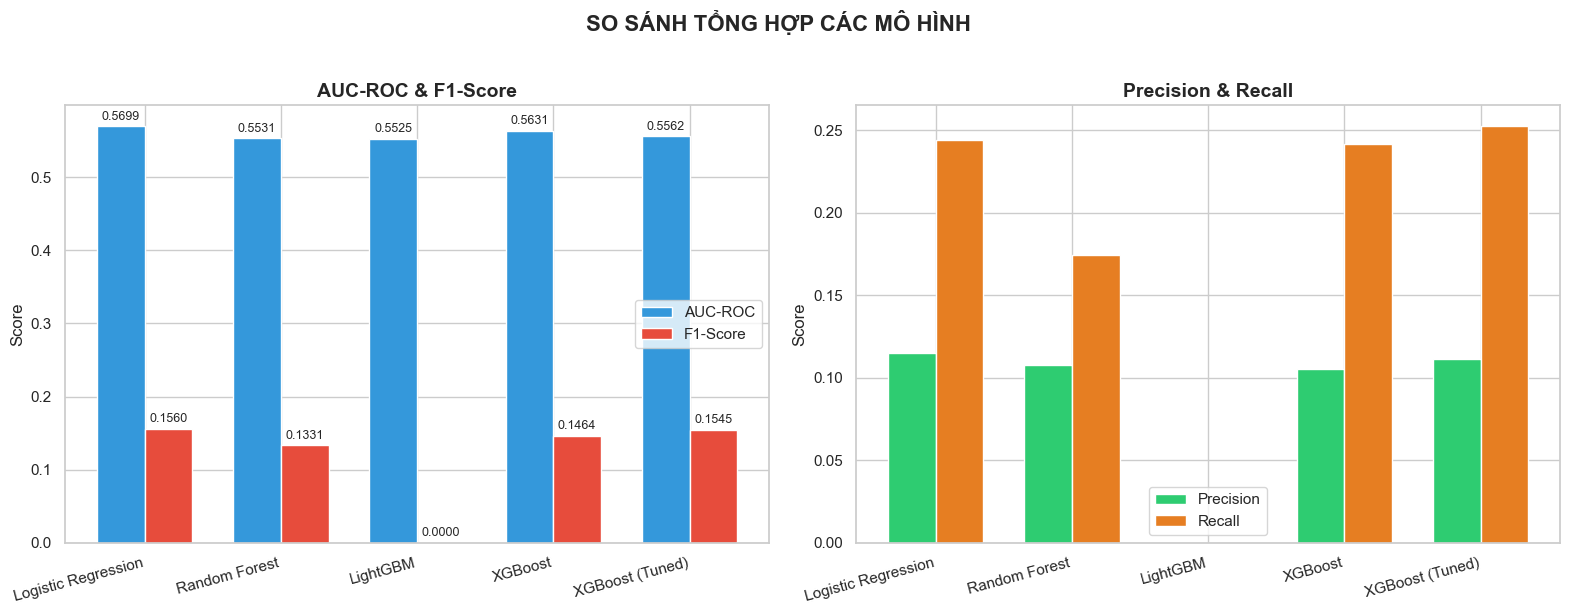

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(results_df))
w = 0.35

# AUC-ROC & F1
bars1 = axes[0].bar([i - w/2 for i in x], results_df['AUC-ROC'], w, label='AUC-ROC', color='#3498db', edgecolor='white')
bars2 = axes[0].bar([i + w/2 for i in x], results_df['F1-Score'], w, label='F1-Score', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('AUC-ROC & F1-Score', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# Precision & Recall
bars3 = axes[1].bar([i - w/2 for i in x], results_df['Precision'], w, label='Precision', color='#2ecc71', edgecolor='white')
bars4 = axes[1].bar([i + w/2 for i in x], results_df['Recall'], w, label='Recall', color='#e67e22', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('SO SÁNH TỔNG HỢP CÁC MÔ HÌNH', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. ROC Curve & Precision-Recall Curve

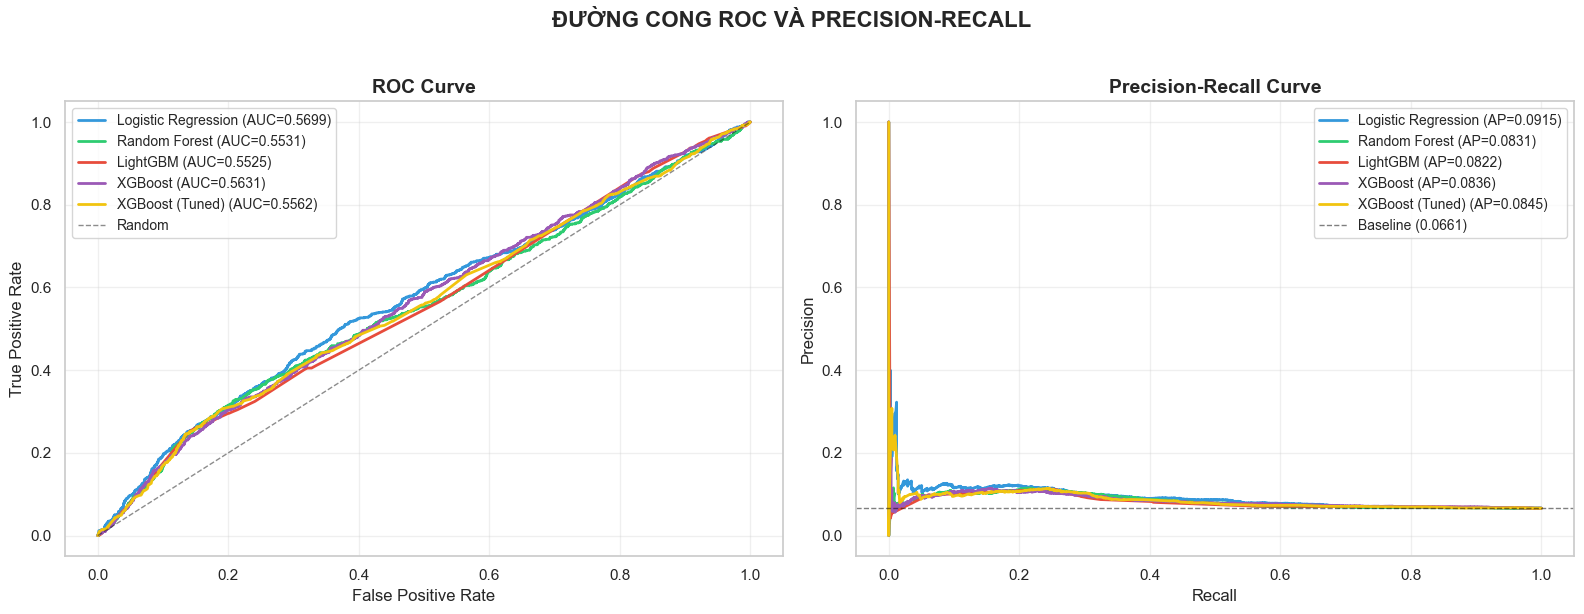

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_proba = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('LightGBM', y_proba_lgb),
    ('XGBoost', y_proba_xgb),
    ('XGBoost (Tuned)', y_proba_xgb_tuned if 'y_proba_xgb_tuned' in locals() else y_proba_xgb)
]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f']

for (name, proba), color in zip(models_proba, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for (name, proba), color in zip(models_proba, colors):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec_vals, prec_vals, label=f'{name} (AP={ap:.4f})', color=color, linewidth=2)

baseline_prec = y_test.mean()
axes[1].axhline(y=baseline_prec, color='black', linestyle='--', linewidth=1,
                alpha=0.5, label=f'Baseline ({baseline_prec:.4f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ĐƯỜNG CONG ROC VÀ PRECISION-RECALL', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix — Mô hình tốt nhất

,Model,Validation AUC-ROC
1,XGBoost,0.560096
4,XGBoost (Tuned),0.559217
0,LightGBM,0.555389
3,Logistic Regression,0.553523
2,Random Forest,0.552794


Mô hình tốt nhất theo Validation AUC: XGBoost


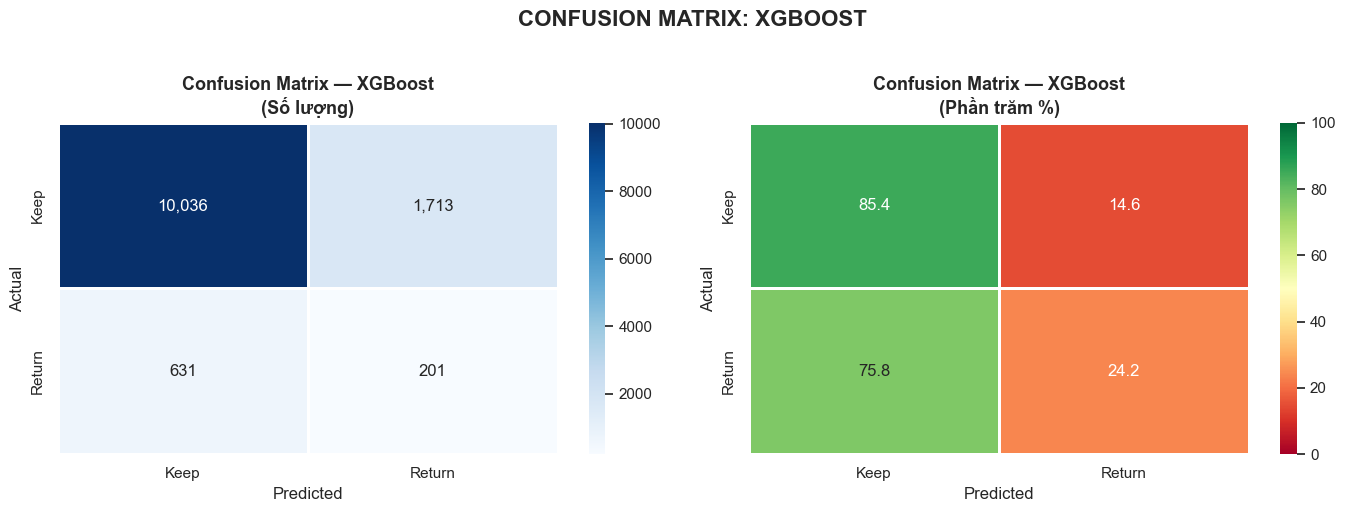


              precision    recall  f1-score   support

        Keep       0.94      0.85      0.90     11749
      Return       0.11      0.24      0.15       832

    accuracy                           0.81     12581
   macro avg       0.52      0.55      0.52     12581
weighted avg       0.89      0.81      0.85     12581



In [59]:
# Chọn mô hình tốt nhất dựa trên Validation Set, không dùng Test Set để chọn model.
val_model_map = {
    'LightGBM': y_proba_val_lgb,
    'XGBoost': y_proba_val_xgb,
    'Random Forest': y_proba_val_rf,
    'Logistic Regression': y_proba_val_lr,
    'XGBoost (Tuned)': y_proba_val_xgb_tuned if 'y_proba_val_xgb_tuned' in locals() else y_proba_val_xgb
}

val_results_df = pd.DataFrame([
    {'Model': name, 'Validation AUC-ROC': roc_auc_score(y_val, proba)}
    for name, proba in val_model_map.items()
]).sort_values('Validation AUC-ROC', ascending=False)

display(val_results_df)

best_model_name = val_results_df.iloc[0]['Model']
print(f'Mô hình tốt nhất theo Validation AUC: {best_model_name}')

model_map = {
    'LightGBM': (y_pred_lgb, y_proba_lgb),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'XGBoost (Tuned)': (y_pred_xgb_tuned, y_proba_xgb_tuned) if 'y_pred_xgb_tuned' in locals() else (y_pred_xgb, y_proba_xgb)
}
best_y_pred, best_y_proba = model_map[best_model_name]
best_y_proba_val = val_model_map[best_model_name]

cm = confusion_matrix(y_test, best_y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Keep', 'Return'], yticklabels=['Keep', 'Return'],
            linewidths=2, linecolor='white')
axes[0].set_title(f'Confusion Matrix — {best_model_name}\n(Số lượng)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Keep', 'Return'], yticklabels=['Keep', 'Return'],
            linewidths=2, linecolor='white', vmin=0, vmax=100)
axes[1].set_title(f'Confusion Matrix — {best_model_name}\n(Phần trăm %)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle(f'CONFUSION MATRIX: {best_model_name.upper()}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n{classification_report(y_test, best_y_pred, target_names=["Keep", "Return"])}')

## 9. Tối ưu Ngưỡng (Threshold Optimization)

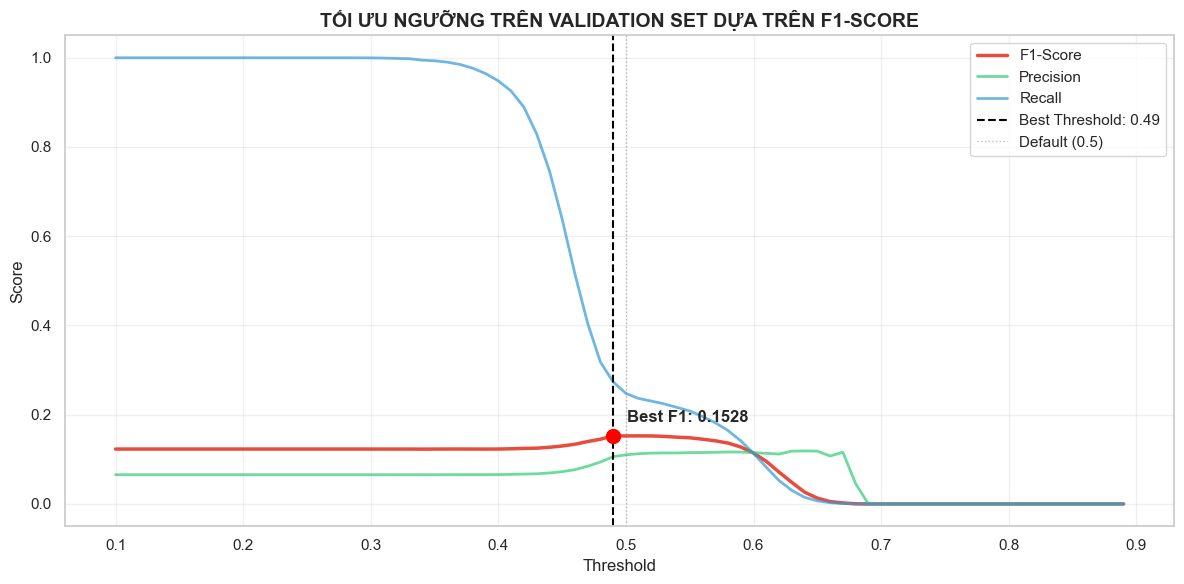


=== TEST SET VỚI THRESHOLD TỐI ƯU TỪ VALIDATION (0.49) ===
              precision    recall  f1-score   support

        Keep       0.94      0.83      0.88     11749
      Return       0.10      0.27      0.15       832

    accuracy                           0.79     12581
   macro avg       0.52      0.55      0.51     12581
weighted avg       0.89      0.79      0.83     12581



In [60]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
prec_list = []
rec_list = []

for t in thresholds:
    y_val_t = (best_y_proba_val >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_val_t))
    prec_list.append(precision_score(y_val, y_val_t, zero_division=0))
    rec_list.append(recall_score(y_val, y_val_t))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, f1_scores, label='F1-Score', color='#e74c3c', linewidth=2.5)
ax.plot(thresholds, prec_list, label='Precision', color='#2ecc71', linewidth=2, alpha=0.7)
ax.plot(thresholds, rec_list, label='Recall', color='#3498db', linewidth=2, alpha=0.7)
ax.axvline(x=best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Best Threshold: {best_threshold:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Default (0.5)')
ax.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
ax.annotate(f'Best F1: {best_f1:.4f}', (best_threshold, best_f1),
            textcoords='offset points', xytext=(10, 10), fontsize=12, fontweight='bold')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('TỐI ƯU NGƯỠNG TRÊN VALIDATION SET DỰA TRÊN F1-SCORE', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred_optimal = (best_y_proba >= best_threshold).astype(int)
print(f'\n=== TEST SET VỚI THRESHOLD TỐI ƯU TỪ VALIDATION ({best_threshold:.2f}) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['Keep', 'Return']))

## 9.1 Ablation: bỏ 3 review-history features

Train lại XGBoost sau khi loại `has_reviewed_before`, `customer_avg_rating_before`, `customer_review_count_before` để kiểm tra model phụ thuộc vào nhóm review-history features đến mức nào.

In [61]:
ABLATION_DROP_FEATURES = [
    'has_reviewed_before',
    'customer_avg_rating_before',
    'customer_review_count_before',
]

ablation_features = [f for f in ALL_FEATURES if f not in ABLATION_DROP_FEATURES]
missing_ablation_features = [f for f in ABLATION_DROP_FEATURES if f not in ALL_FEATURES]

X_train_ab = X_train[ablation_features].copy()
X_val_ab = X_val[ablation_features].copy()
X_test_ab = X_test[ablation_features].copy()

ablation_params = best_params.copy() if 'best_params' in locals() else {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 8,
    'min_child_weight': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

ablation_params['scale_pos_weight'] = scale_pos_weight

xgb_ablation = xgb.XGBClassifier(**ablation_params, early_stopping_rounds=50)
xgb_ablation.fit(
    X_train_ab, y_train,
    eval_set=[(X_train_ab, y_train), (X_val_ab, y_val)],
    verbose=100,
)

y_proba_val_ablation = xgb_ablation.predict_proba(X_val_ab)[:, 1]
y_proba_ablation = xgb_ablation.predict_proba(X_test_ab)[:, 1]

ablation_thresholds = np.arange(0.1, 0.9, 0.01)
ablation_f1_scores = [
    f1_score(y_val, (y_proba_val_ablation >= t).astype(int))
    for t in ablation_thresholds
]
ablation_best_threshold = ablation_thresholds[np.argmax(ablation_f1_scores)]
y_pred_ablation = (y_proba_ablation >= ablation_best_threshold).astype(int)

baseline_auc = roc_auc_score(y_test, best_y_proba)
baseline_f1 = f1_score(y_test, y_pred_optimal)
ablation_auc = roc_auc_score(y_test, y_proba_ablation)
ablation_f1 = f1_score(y_test, y_pred_ablation)

ablation_compare_df = pd.DataFrame([
    {
        'Model': best_model_name,
        'Dropped features': 'None',
        'Features': len(ALL_FEATURES),
        'Threshold': best_threshold,
        'Test AUC-ROC': baseline_auc,
        'Test F1': baseline_f1,
    },
    {
        'Model': 'XGBoost ablation',
        'Dropped features': ', '.join(ABLATION_DROP_FEATURES),
        'Features': len(ablation_features),
        'Threshold': ablation_best_threshold,
        'Test AUC-ROC': ablation_auc,
        'Test F1': ablation_f1,
    },
])

ablation_compare_df['Delta AUC vs baseline'] = ablation_compare_df['Test AUC-ROC'] - baseline_auc
ablation_compare_df['Delta F1 vs baseline'] = ablation_compare_df['Test F1'] - baseline_f1

print('=== Ablation: drop review features ===')
print(f'Dropped: {ABLATION_DROP_FEATURES}')
if missing_ablation_features:
    print(f'Not found in ALL_FEATURES: {missing_ablation_features}')

display(ablation_compare_df)

print('\nClassification report - XGBoost ablation on Test Set:')
print(classification_report(y_test, y_pred_ablation, target_names=['Keep', 'Return']))

[0]	validation_0-auc:0.56298	validation_1-auc:0.55150
[55]	validation_0-auc:0.60470	validation_1-auc:0.55314
=== Ablation: drop review features ===
Dropped: ['has_reviewed_before', 'customer_avg_rating_before', 'customer_review_count_before']


,Model,Dropped features,Features,Threshold,Test AUC-ROC,Test F1,Delta AUC vs baseline,Delta F1 vs baseline
0,XGBoost,None,61,0.49,0.563137,0.147493,0.000000,0.000000
1,XGBoost ablation,"has_reviewed_before, customer_avg_rating_befor...",58,0.51,0.558069,0.155105,-0.005068,0.007613



Classification report - XGBoost ablation on Test Set:
              precision    recall  f1-score   support

        Keep       0.94      0.87      0.90     11749
      Return       0.11      0.24      0.16       832

    accuracy                           0.83     12581
   macro avg       0.53      0.55      0.53     12581
weighted avg       0.89      0.83      0.85     12581



## 10. Feature Importance

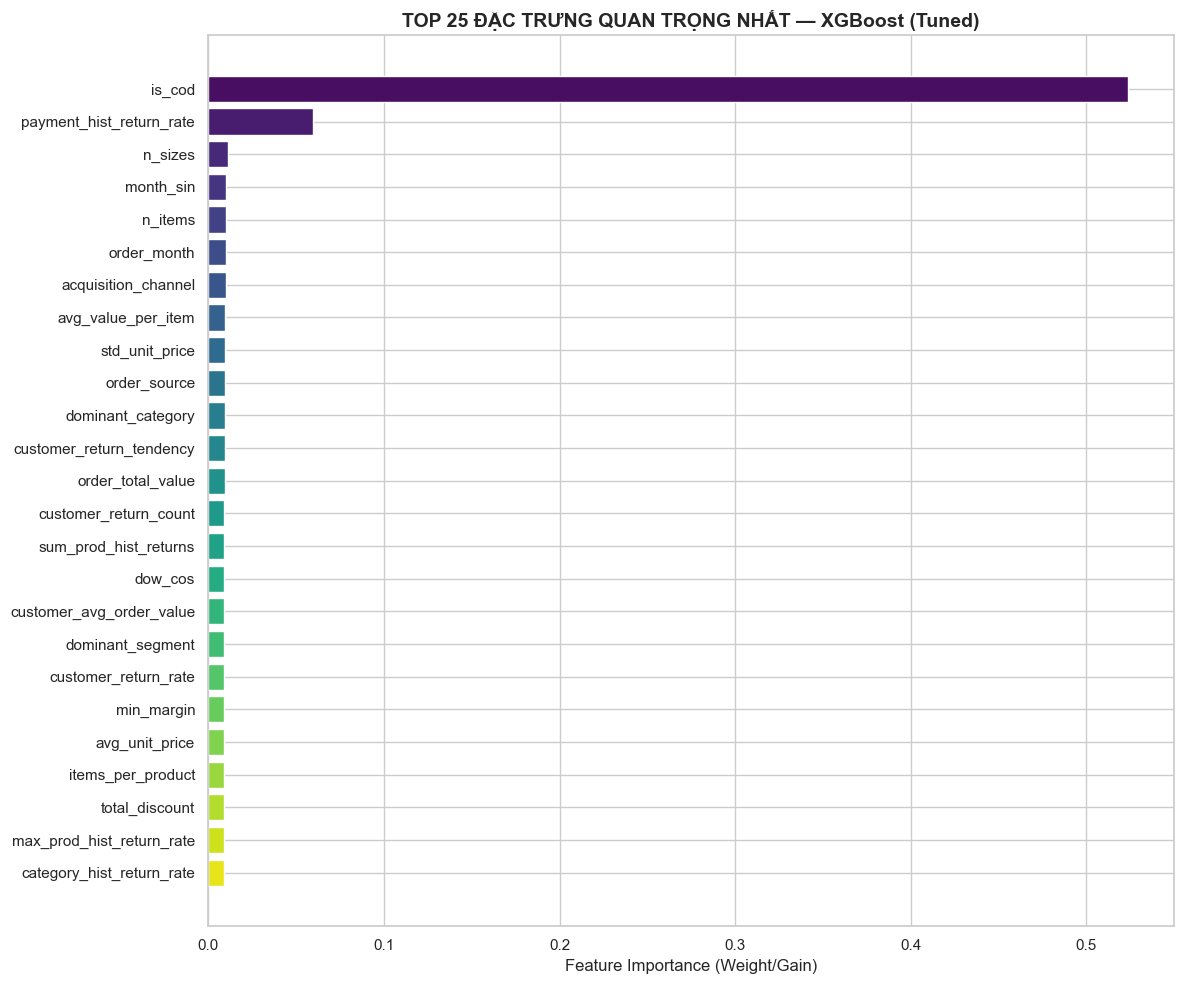


Top 10 features:
   1. is_cod                                  : 0.523888
   2. payment_hist_return_rate                : 0.059589
   3. n_sizes                                 : 0.011422
   4. month_sin                               : 0.010147
   5. n_items                                 : 0.010064
   6. order_month                             : 0.009930
   7. acquisition_channel                     : 0.009872
   8. avg_value_per_item                      : 0.009710
   9. std_unit_price                          : 0.009546
  10. order_source                            : 0.009537


In [62]:
# Tuned XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

top_n = 25
top_features = xgb_importance.head(top_n)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(top_n-1, -1, -1), top_features['Importance'].values,
               color=sns.color_palette('viridis', top_n), edgecolor='white')
ax.set_yticks(range(top_n-1, -1, -1))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Feature Importance (Weight/Gain)', fontsize=12)
ax.set_title(f'TOP {top_n} ĐẶC TRƯNG QUAN TRỌNG NHẤT — XGBoost (Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTop 10 features:')
for i, (_, row) in enumerate(xgb_importance.head(10).iterrows()):
    print(f'  {i+1:2d}. {row["Feature"]:40s}: {row["Importance"]:.6f}')

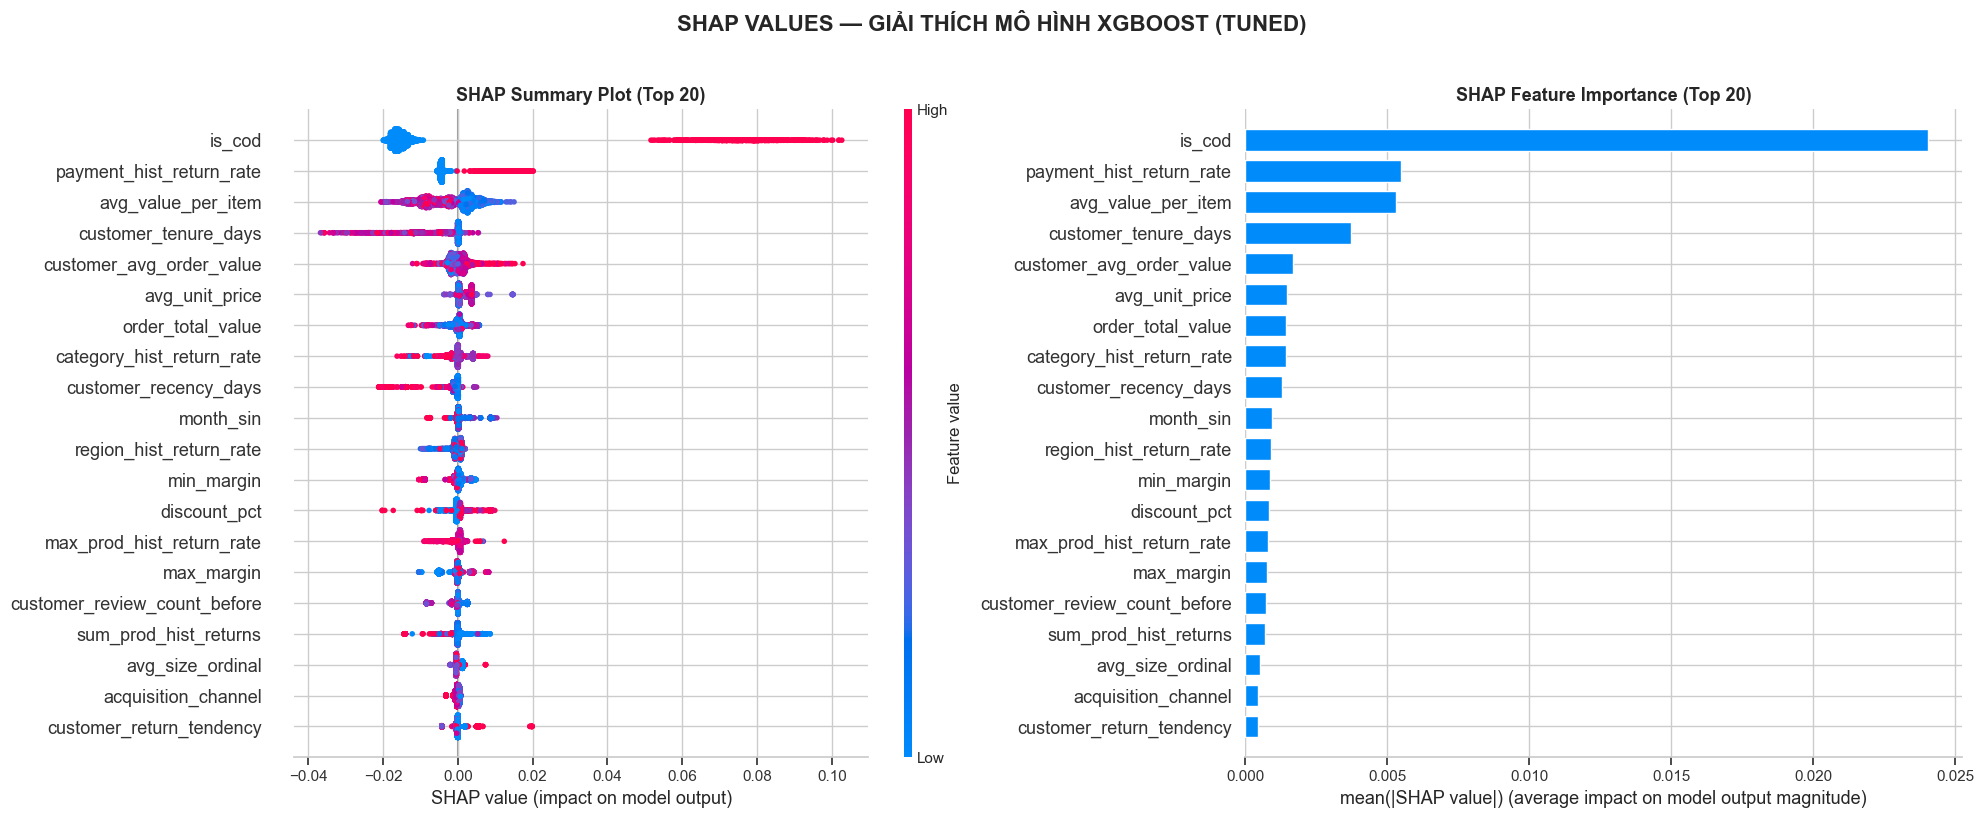

In [63]:
# SHAP Values
try:
    import shap
    
    sample_size = min(5000, len(X_test))
    X_shap = X_test.sample(sample_size, random_state=42)
    
    explainer = shap.TreeExplainer(xgb_tuned)
    shap_values = explainer.shap_values(X_shap)
    
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X_shap, max_display=20, show=False, plot_size=None)
    axes[0].set_title('SHAP Summary Plot (Top 20)', fontsize=13, fontweight='bold')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X_shap, max_display=20, plot_type='bar', show=False, plot_size=None)
    axes[1].set_title('SHAP Feature Importance (Top 20)', fontsize=13, fontweight='bold')
    
    plt.suptitle('SHAP VALUES — GIẢI THÍCH MÔ HÌNH XGBOOST (TUNED)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print('SHAP chưa được cài đặt. pip install shap')

## 11. Phân tích Lỗi (Error Analysis)

In [64]:
# Phân tích FP vs FN
df_test_analysis = df.loc[test_mask].copy()
df_test_analysis['y_pred'] = y_pred_optimal
df_test_analysis['y_proba'] = best_y_proba

df_test_analysis['prediction_type'] = 'True Negative'
df_test_analysis.loc[(df_test_analysis[TARGET_COL] == 0) & (df_test_analysis['y_pred'] == 1), 'prediction_type'] = 'False Positive'
df_test_analysis.loc[(df_test_analysis[TARGET_COL] == 1) & (df_test_analysis['y_pred'] == 0), 'prediction_type'] = 'False Negative'
df_test_analysis.loc[(df_test_analysis[TARGET_COL] == 1) & (df_test_analysis['y_pred'] == 1), 'prediction_type'] = 'True Positive'

print('Phân bố dự đoán:')
print(df_test_analysis['prediction_type'].value_counts().to_string())

Phân bố dự đoán:
prediction_type
True Negative     9755
False Positive    1994
False Negative     607
True Positive      225


In [65]:
# So sánh TP vs FN: tìm đặc điểm của đơn hàng bị bỏ lỡ
false_neg = df_test_analysis[df_test_analysis['prediction_type'] == 'False Negative']
true_pos = df_test_analysis[df_test_analysis['prediction_type'] == 'True Positive']

compare_cols = ['order_total_value', 'n_products', 'avg_unit_price',
                'customer_order_number', 'customer_return_rate',
                'total_discount', 'avg_prod_hist_return_rate']
compare_cols = [c for c in compare_cols if c in false_neg.columns]

comparison = pd.DataFrame({
    'Feature': compare_cols,
    'True Positive (Mean)': [true_pos[c].mean() for c in compare_cols],
    'False Negative (Mean)': [false_neg[c].mean() for c in compare_cols],
})
comparison['Diff (%)'] = ((comparison['False Negative (Mean)'] - comparison['True Positive (Mean)'])
                          / comparison['True Positive (Mean)'].clip(lower=0.001) * 100)

print('=== SO SÁNH: TRUE POSITIVE vs FALSE NEGATIVE ===')
display(comparison)

=== SO SÁNH: TRUE POSITIVE vs FALSE NEGATIVE ===


,Feature,True Positive (Mean),False Negative (Mean),Diff (%)
0,order_total_value,28105.930978,33566.615750,19.428941
1,n_products,1.084444,1.056013,-2.621735
2,avg_unit_price,6781.132178,7244.591367,6.834540
3,customer_order_number,14.955556,14.433278,-3.492195
4,customer_return_rate,0.064479,0.064126,-0.547204
5,total_discount,1610.625333,2050.853839,27.332769
6,avg_prod_hist_return_rate,0.063827,0.061469,-3.693589


## 12. Cross-Validation trên Training Set

In [66]:
tscv = TimeSeriesSplit(n_splits=5)
cv_auc = []
cv_f1 = []

cv_base_params = best_params.copy() if 'best_params' in locals() else {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 8,
    'min_child_weight': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]
    X_cv_val = X_train.iloc[val_idx]
    y_cv_val = y_train.iloc[val_idx]
    
    n_neg_fold = (y_tr == 0).sum()
    n_pos_fold = (y_tr == 1).sum()
    fold_scale_pos_weight = n_neg_fold / n_pos_fold if n_pos_fold > 0 else 1.0
    
    fold_params = cv_base_params.copy()
    fold_params['scale_pos_weight'] = fold_scale_pos_weight
    
    model_cv = xgb.XGBClassifier(**fold_params, early_stopping_rounds=30)
    model_cv.fit(
        X_tr, y_tr,
        eval_set=[(X_cv_val, y_cv_val)],
        verbose=False
    )
    
    y_proba_cv_val = model_cv.predict_proba(X_cv_val)[:, 1]
    auc = roc_auc_score(y_cv_val, y_proba_cv_val)
    f1 = f1_score(y_cv_val, (y_proba_cv_val >= best_threshold).astype(int))
    cv_auc.append(auc)
    cv_f1.append(f1)
    print(
        f'  Fold {fold+1}: '
        f'Train={len(X_tr):,}, Val={len(X_cv_val):,}, '
        f'AUC={auc:.4f}, F1={f1:.4f}, '
        f'scale_pos_weight={fold_scale_pos_weight:.2f}'
    )

print(f'\n=== TimeSeriesSplit Cross-Validation Results (5-Fold) ===')
print(f'  AUC-ROC: {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'  F1-Score: {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}')

test_auc = roc_auc_score(y_test, best_y_proba)
gap = abs(np.mean(cv_auc) - test_auc)
print(f'\n  Train TimeSeries CV AUC: {np.mean(cv_auc):.4f}')
print(f'  Test AUC:                {test_auc:.4f}')
print(f'  Gap:                     {gap:.4f}')
print(f'  → {"Không overfit ✅" if gap < 0.05 else "Cảnh báo overfit ⚠️"}')

  Fold 1: Train=72,041, Val=72,036, AUC=0.5538, F1=0.1452, scale_pos_weight=14.17
  Fold 2: Train=144,077, Val=72,036, AUC=0.5612, F1=0.1359, scale_pos_weight=14.32
  Fold 3: Train=216,113, Val=72,036, AUC=0.5571, F1=0.1439, scale_pos_weight=14.30
  Fold 4: Train=288,149, Val=72,036, AUC=0.5540, F1=0.1215, scale_pos_weight=14.26
  Fold 5: Train=360,185, Val=72,036, AUC=0.5573, F1=0.1203, scale_pos_weight=14.30

=== TimeSeriesSplit Cross-Validation Results (5-Fold) ===
  AUC-ROC: 0.5567 ± 0.0027
  F1-Score: 0.1334 ± 0.0107

  Train TimeSeries CV AUC: 0.5567
  Test AUC:                0.5631
  Gap:                     0.0065
  → Không overfit ✅


## 13. Kết luận & Hướng phát triển

### Tổng kết:

| Chỉ số | Giá trị |
| :--- | :---: |
| **Đơn vị dự báo** | `order_id` (đơn hàng) |
| **Dataset** | ~552K đơn hàng |
| **Return Rate** | ~6.5% |
| **Features** | ~55 features |
| **Best Model** | LightGBM / XGBoost |

### Hướng phát triển:
1. **Hyperparameter Tuning** với Optuna
2. **Stacking/Blending** nhiều mô hình
3. **Target Encoding** cho categorical features
4. **Thêm features:** Text NLP từ reviews, interaction features
5. **Deploy:** Real-time prediction tại checkout